# SIT742 2026T2 Assignment 1 Starter Notebook: Critical Analysis

This starter notebook is the working file for SIT742 Assignment 1. Complete the code cells, replace required `None` placeholders, and write the required explanations in the markdown cells. The Assignment Specification is the authoritative source for all requirements.

Keep the required section headings and object names, and run the notebook from top to bottom before exporting your PDF.

## Student Details

- Student name: `{{Tyson Mitchell}}`
- Student ID: `{{225734851}}`
- Student email: `{{s225734851@deakin.edu.au}}`
- Submission date: `{{06/08/2026}}`

In [1]:
# Complete this cell before submission. These values support marking and feedback workflows.
STUDENT_INFO = {
    "student_id": "225734851",
    "student_name": "Tyson Mitchell",
    "deakin_email": "s225734851@deakin.edu.au",
    "unit": "SIT742",
    "assignment": "A1",
    "teaching_period": "2026T2",
}

In [2]:
# Required object names used by the notebook and marking and feedback workflow.
A1_REQUIRED_OBJECTS = [
    "raw_market_data",
    "schema_audit",
    "clean_market_data",
    "tidy_arrivals",
    "annual_summary",
    "feature_table",
    "selected_sii_features",
    "sii_summary",
]

## Contents

- [Student details](#student-details)
- [Assignment overview](#assignment-overview)
- [Setup and dataset constants](#setup-and-dataset-constants)
- [Part I: Python Programming Tasks](#part-i-python-programming-tasks)
  - [Question 1](#question-1-normalise_column_labelslabels-5-marks)
  - [Question 2](#question-2-validate_monthly_date_rangedate_values-start2012-01-end2018-12-5-marks)
  - [Question 3](#question-3-make_tidy_arrival_tablemarket_frames-5-marks)
  - [Question 4](#question-4-summarise_numeric_columnsdf-excludedate-5-marks)
  - [Question 5](#question-5-rolling_mean_manualvalues-window-5-marks)
  - [Question 6](#question-6-detect_local_extremavalues-5-marks)
- [Part II: HK2012-2018 Dataset Analysis and Critical Interpretation](#part-ii-hk2012-2018-dataset-analysis-and-critical-interpretation)
  - [Question 7](#question-7-data-access-and-schema-audit-10-marks)
  - [Question 8](#question-8-cleaning-and-reproducible-analysis-tables-10-marks)
  - [Question 9](#question-9-exploratory-data-analysis-and-cross-market-comparison-15-marks)
  - [Question 10](#question-10-feature-engineering-and-sii-analysis-15-marks)
  - [Question 11](#question-11-critical-interpretation-limitations-and-project-planning-insight-10-marks)
- [Part III: Transfer and Reflection](#part-iii-transfer-and-reflection)
  - [Question 12](#question-12-transfer-and-reflection-10-marks)
- [Dataset source and acknowledgement](#dataset-source-and-acknowledgement-placeholder)
- [Reproducibility checklist](#reproducibility-checklist)
- [Submission checklist](#submission-checklist)

## Assignment Overview

Assignment 1 contains three parts:

- Part I: Python Programming Tasks
- Part II: HK2012-2018 Dataset Analysis and Critical Interpretation
- Part III: Transfer and Reflection

Part III is a discussion/reflection task only. You are not required to download, clean, or analyse the ISF-TDF2023 dataset.

Submit your completed notebook and an exported PDF through CloudDeakin via Assignments located under Assessment. Students aiming for High Distinction may also submit an optional video; video may also be requested for verification. The video is not a separate compulsory scored component.

## Setup and dataset constants

Keep imports minimal and relevant. Add comments if you use extra packages.

In [3]:
from pathlib import Path

import pandas as pd
import re #regex is used to filter column names ending with ".x", where x = a number 
import matplotlib.pyplot as plt #will be used for the plots in Q9

### Dataset constants

Use the public TULIP Lab `HK2012-2018` dataset.

Dataset repository page:
https://github.com/tulip-lab/open-data/tree/main/HK2012-2018

Approved raw URL base for loading CSV files in Python:
`https://raw.githubusercontent.com/tulip-lab/open-data/main/HK2012-2018`

Use the repository page to inspect files and documentation. Use the raw URL base in Python loading code. Do not use the GitHub repository page URL inside `pandas.read_csv()`.

These constants are provided for later use in Part II. You will complete the actual data loading and schema audit under Question 7.

In [4]:
RAW_BASE = "https://raw.githubusercontent.com/tulip-lab/open-data/main/HK2012-2018"

CORE_MARKET_FILES = {
    "Australia": "Australia.csv",
    "United States": "United_States.csv",
    "Thailand": "Thailand.csv",
}

OPTIONAL_MARKET_FILES = {
    "Philippines": "Philippine.csv",
    "Singapore": "Singapore.csv",
    "United Kingdom": "United_Kingdom.csv",
}

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

## Part I: Python Programming Tasks

Complete the six required functions below. Keep the function names and signatures unchanged.

The Part I illustrative examples use small toy inputs to clarify the required behaviour. They are not hidden tests. Your functions should work for other valid inputs that follow the same specification.

### Question 1: `normalise_column_labels(labels)` [5 marks]

Your task:
Write a function that converts a sequence of raw column labels into cleaned, analysis-ready column labels.

Input:
- `labels`: a sequence of column-label values.

Output:
- Return `(cleaned_labels, label_map)`.
- `cleaned_labels` must be a list of cleaned column names.
- `label_map` must be index-aware, preferably a list of records with `index`, `original`, and `cleaned`.

Output field meanings:
- `cleaned_labels`: cleaned labels in the same order as the input.
- `label_map`: an index-aware mapping from each original input position to its cleaned label.

Constraints:
- strip leading/trailing whitespace;
- convert labels to lowercase;
- replace one or more internal whitespace characters with one underscore;
- use suffixes `_2`, `_3`, etc. when cleaned labels are duplicated;
- preserve original order.

Illustrative example:
```python
labels = [" Date ", "Arrival", "Search Index", "Search  Index", "Arrival "]
```
Expected output format:
```python
cleaned_labels = ["date", "arrival", "search_index", "search_index_2", "arrival_2"]
label_map = [
    {"index": 0, "original": " Date ", "cleaned": "date"},
    {"index": 1, "original": "Arrival", "cleaned": "arrival"},
    {"index": 2, "original": "Search Index", "cleaned": "search_index"},
    {"index": 3, "original": "Search  Index", "cleaned": "search_index_2"},
    {"index": 4, "original": "Arrival ", "cleaned": "arrival_2"},
]
```

Dataset connection:
This function is useful in Part II because real CSV files may contain spaces, inconsistent capitalisation, or repeated-looking column names.

In [5]:
def normalise_column_labels(labels):
    cleaned_labels = []
    label_map = []
    seen = {} # tracks how many times each cleaned name has occurred so far
    for i, label in enumerate(labels): #enumerate gives both position (i) and value(label)
        #removes trailing white space, convert to lowercase, split strings into lists of words then join the words with an underscore 
        cleaned = "_".join(label.strip().lower().split())
        #identifies the occurence of the name 
        count = seen.get(cleaned, 0) + 1
        seen[cleaned] = count #update the count for future duplicates 
        if count == 1:
            final = cleaned
        else:
            final = f"{cleaned}_{count}" # append suffix for duplicates
        cleaned_labels.append(final)
        label_map.append({"index": i, "original": label, "cleaned": final})
    return cleaned_labels, label_map

labels = [" Date ", "Arrival", "Search Index", "Search  Index", "Arrival "]
print(normalise_column_labels(labels))

(['date', 'arrival', 'search_index', 'search_index_2', 'arrival_2'], [{'index': 0, 'original': ' Date ', 'cleaned': 'date'}, {'index': 1, 'original': 'Arrival', 'cleaned': 'arrival'}, {'index': 2, 'original': 'Search Index', 'cleaned': 'search_index'}, {'index': 3, 'original': 'Search  Index', 'cleaned': 'search_index_2'}, {'index': 4, 'original': 'Arrival ', 'cleaned': 'arrival_2'}])


### Question 2: `validate_monthly_date_range(date_values, start="2012-01", end="2018-12")` [5 marks]

Your task:
Write a function that checks whether a sequence of date values can be parsed as monthly dates and covers every month from the required start month to the required end month.

Input:
- `date_values`: a sequence of date-like values.
- `start`: required start month as a string such as `"2012-01"`.
- `end`: required end month as a string such as `"2018-12"`.

Output:
- Return a dictionary with deterministic keys.
- Include at least `is_complete`, `start`, `end`, `n_periods`, `missing_months`, and `extra_months`.

Output field meanings:
- `is_complete`: `True` if every expected month from `start` to `end` is present and no required month is missing; otherwise `False`.
- `start`: the required start month used for validation, formatted as `YYYY-MM`.
- `end`: the required end month used for validation, formatted as `YYYY-MM`.
- `n_periods`: the number of distinct valid monthly periods found in `date_values` after parsing and normalising to months.
- `missing_months`: expected months between `start` and `end` that are not present in `date_values`, formatted as `YYYY-MM` strings.
- `extra_months`: parsed months that are present in `date_values` but fall outside the required `start` to `end` range, formatted as `YYYY-MM` strings.

Constraints:
- parse values into monthly periods or month-start timestamps;
- check whether all expected months from `start` to `end` are present;
- report missing months as strings such as `"2012-03"`;
- report months outside the expected range in `extra_months`;
- if the same month appears more than once, count it once in `n_periods` after parsing, but still detect missing and extra months correctly.

Illustrative example:
```python
date_values = ["2012-01", "2012-02", "2012-04"]
result = validate_monthly_date_range(date_values, start="2012-01", end="2012-04")
```
Expected output shape:
```python
{
    "is_complete": False,
    "start": "2012-01",
    "end": "2012-04",
    "n_periods": 3,
    "missing_months": ["2012-03"],
    "extra_months": [],
}
```
Here, `n_periods` is `3` because the input contains three distinct parsed months: `2012-01`, `2012-02`, and `2012-04`.

Dataset connection:
This function is directly useful in Part II when verifying that each required market file contains a complete monthly series from 2012-01 to 2018-12.

In [6]:
def validate_monthly_date_range(date_values, start="2012-01", end="2018-12"):
    # parse dates into a period with monthly frequency 
    parsed = [pd.Period(value, freq="M") for value in date_values]
    # extracting all distinct months 
    unique_parsed = set(parsed)
    n_periods = len(unique_parsed)
    #range is used to find all of the months between start and end 
    expected = pd.period_range(start=start, end=end, freq='M')
    # find months present in the data but outside the required range
    extra_months = [item for item in unique_parsed if item not in expected]
    # find months required but missing from the data
    missing_months = [item for item in expected if item not in unique_parsed]
    # converting to a string 
    extra_months = [str(date_value) for date_value in extra_months]
    missing_months = [str(date_value) for date_value in missing_months]
    if len(missing_months) == 0:
        is_complete = True
    else:
        is_complete = False
    result = {
        "is_complete": is_complete,
        "start": start,
        "end": end,
        "n_periods": n_periods,
        "missing_months": missing_months,
        "extra_months": extra_months,
}
    return result 

### Question 3: `make_tidy_arrival_table(market_frames)` [5 marks]

Your task:
Write a function that combines arrival columns from multiple market DataFrames into one tidy table with one row per market-month.

Input:
- `market_frames`: a dictionary where keys are market names and values are DataFrames containing at least a date column and an arrival column.

Output:
- Return a pandas DataFrame with at least `date`, `market`, and `arrival` columns.

Constraints:
- preserve all markets provided in `market_frames`;
- add the market name from the dictionary key;
- keep only the required tidy columns unless you clearly document additional columns;
- sort by `market` and `date`, or otherwise produce a clearly reproducible order;
- the function may preserve the original date values. Date parsing and monthly-range validation are assessed in Part II. If you parse dates inside this function, do so consistently.

Illustrative example:
```python
market_frames = {
    "Australia": pd.DataFrame({"date": ["2012-01", "2012-02"], "arrival": [100, 120]}),
    "Thailand": pd.DataFrame({"date": ["2012-01", "2012-02"], "arrival": [80, 90]}),
}
```
Expected output shape:

| date | market | arrival |
| --- | --- | ---: |
| 2012-01 | Australia | 100 |
| 2012-02 | Australia | 120 |
| 2012-01 | Thailand | 80 |
| 2012-02 | Thailand | 90 |

Dataset workflow connection:
In Part II, after you load and clean the three required market files, you will have one cleaned DataFrame for each market. Question 3 asks you to write a reusable helper that takes a dictionary of these market-level DataFrames and stacks their arrival series into one tidy table. This tidy table is the same style of object required later as `tidy_arrivals`.

For the real A1 dataset, `market_frames` may correspond to cleaned DataFrames for `Australia`, `United States`, and `Thailand`. Each DataFrame should contain a date column and an arrival column after your cleaning step. The function should add a `market` column using the dictionary key and return one row per market-month.

The illustrative example uses small toy DataFrames. In Part II, the same idea should scale to the required market files.

In [7]:
def make_tidy_arrival_table(market_frames):
    frames = [] #collect the dataframe of each market 
    for market, df in market_frames.items(): #using items to get the key and values 
        df_copy = df.copy()
        df_copy["market"] = market # new column in the dataframe 
        frames.append(df_copy)
    combined_df = pd.concat(frames, ignore_index=True) #get a sequential index 
    combined_df = combined_df.sort_values(["market", "date"])
    combined_df = combined_df[["date", "market", "arrival"]] #just to match the order from the example
    return combined_df

market_frames = {
    "Australia": pd.DataFrame({"date": ["2012-01", "2012-02"], "arrival": [100, 120]}),
    "Thailand": pd.DataFrame({"date": ["2012-01", "2012-02"], "arrival": [80, 90]}),
}
make_tidy_arrival_table(market_frames)

,date,market,arrival
0,2012-01,Australia,100
1,2012-02,Australia,120
2,2012-01,Thailand,80
3,2012-02,Thailand,90


### Question 4: `summarise_numeric_columns(df, exclude=("date",))` [5 marks]

Your task:
Write a function that inspects the columns of a DataFrame and summarises which columns can be treated as numeric analysis columns.

Input:
- `df`: a pandas DataFrame.
- `exclude`: column names to exclude from numeric-column checking.

Output:
- Return a summary DataFrame or dictionary with clear fields.
- Recommended return format: a pandas DataFrame with `column`, `can_convert_numeric`, `n_missing`, `n_unique`, and `example_value`.

Output field meanings:
- `can_convert_numeric`: `True` if the column is already numeric or can be converted to numeric without creating invalid values for the non-missing entries.
- `example_value`: one representative non-missing value from the original column, where available.

Constraints:
- exclude columns listed in `exclude`;
- determine which remaining columns are numeric or can be converted to numeric;
- `can_convert_numeric` should indicate whether the column is already numeric or can be safely converted to numeric for analysis;
- include enough information to support schema audit and SII feature identification.

Illustrative example:
```python
df = pd.DataFrame({
    "date": ["2012-01", "2012-02"],
    "arrival": [100, 120],
    "hotel search": [0.3, 0.4],
    "note": ["ok", "ok"],
})
```
Expected output shape:

| column | can_convert_numeric | n_missing | n_unique | example_value |
| --- | --- | ---: | ---: | --- |
| arrival | True | 0 | 2 | 100 |
| hotel search | True | 0 | 2 | 0.3 |
| note | False | 0 | 1 | ok |

Dataset connection:
This function helps identify arrival and Search Intensity Index columns before feature engineering in Part II.

In [8]:
def summarise_numeric_columns(df, exclude=("date",)):
    records = [] #empty list for records 
    # remaining columns are the columns not listed in exclude 
    remaining_columns = [column for column in df.columns if column not in exclude]
    for column in remaining_columns:
        #extract data for each column
        col_data = df[column] 
        # missing values are the sum of null values
        n_missing = col_data.isna().sum()
        n_unique = col_data.nunique()
        # not na is used to find values that are not null
        non_missing = col_data[col_data.notna()]
        if len(non_missing) == 0: #in case of fully null columns 
            example_value = None
        else:
            example_value = non_missing.iloc[0] #first value
            #check if column is already numeric 
        if pd.api.types.is_numeric_dtype(non_missing):
            can_convert_numeric = True
        else:
            try:
                #try loop, if column is not already numeric, can we convert it
                pd.to_numeric(non_missing)
                can_convert_numeric = True
                #if there is an error while converting, then it becomes false 
            except ValueError:
                can_convert_numeric = False
                #store this columns results as one record 
        records.append({
             "column": column, 
             "can_convert_numeric": can_convert_numeric, 
             "n_missing": n_missing,
             "n_unique": n_unique, 
             "example_value": example_value})
    record_df = pd.DataFrame(records)
    return record_df

### Question 5: `rolling_mean_manual(values, window)` [5 marks]

Your task:
Write a function that manually computes a trailing rolling mean for a numeric sequence, returning `None` until enough previous values are available.

Input:
- `values`: a sequence of numeric values.
- `window`: the trailing window size.

Output:
- Return a list with the same length as `values`.

Output alignment:
- a trailing window uses the current value and the previous `window - 1` values;
- the output index aligns with the input index;
- the first `window - 1` positions should be `None`.

Constraints:
- before a full window is available, return `None`;
- if `window <= 0`, raise `ValueError`;
- do not use `pandas.rolling()` or NumPy rolling helpers.

Illustrative example:
```python
values = [10, 20, 30, 40]
window = 3
```
Expected output:
```python
[None, None, 20.0, 30.0]
```
Explanation:
The first rolling mean is available at index 2 because values 10, 20, and 30 form the first complete window.

Dataset connection:
This is directly related to the `arrival_roll3_mean` and `arrival_roll12_mean` features in Part II.

In [9]:
def rolling_mean_manual(values, window):
    if window <= 0:
        raise ValueError("Window must be a positive integer!") #check for error initially 
    result = []
    for i in range(len(values)):
        if i < window - 1: #first window - 1 positions return none 
            result.append(None)
        else:
            # first value of the window sits at i - (window - 1), final value of the window sits at i
            window_slice = values[i - window + 1 : i + 1] 
            mean_value = sum(window_slice)/len(window_slice) 
            result.append(mean_value)
    return result

### Question 6: `detect_local_extrema(values)` [5 marks]

Your task:
Write a function that finds strict local peaks and valleys in a numeric sequence using neighbouring values.

Input:
- `values`: a sequence of numeric values.

Output:
- Return `{"peaks": [indices], "valleys": [indices]}`.

Returned indices:
- returned indices refer to positions in the original input sequence;
- strict local extrema use immediate neighbours only;
- equal neighbouring values do not count.

Constraints:
- endpoints are not extrema;
- a strict peak occurs when `values[i-1] < values[i] > values[i+1]`;
- a strict valley occurs when `values[i-1] > values[i] < values[i+1]`;
- flat neighbours and plateaus are not counted;
- use zero-based indices.

Illustrative example:
```python
values = [3, 5, 4, 4, 6, 2, 3]
```
Expected output:
```python
{"peaks": [1, 4], "valleys": [5]}
```
Explanation:
Index 1 is a peak because 3 < 5 > 4. Index 4 is a peak because 4 < 6 > 2. Index 5 is a valley because 6 > 2 < 3. The flat pair at indices 2 and 3 is not counted as a local extremum.

Dataset connection:
This is related to identifying local peaks and valleys in monthly arrivals in Part II.

In [10]:
def detect_local_extrema(values):
    peaks = []
    valleys = []
    for i in range(1, len(values) - 1):
         if values[i-1] < values[i] > values[i+1]:
            peaks.append(i)
         elif values[i-1] > values[i] < values[i+1]:
            valleys.append(i)
    result = {"peaks": peaks, "valleys": valleys}
    return result

## Part II: HK2012-2018 Dataset Analysis and Critical Interpretation

Part II is worth 60 marks. Complete Questions 7 to 11 using the three required market files.

Communication, reproducibility, notebook clarity, figure/table labelling, dataset acknowledgement, and avoidance of local absolute paths are assessed within the relevant Part II questions and the final submitted notebook/PDF. They are not a separate scored question.

Part I functions are assessed independently. In Part II, you are encouraged to reuse them where appropriate, but equivalent correct and reproducible implementations are acceptable.

### General Part II requirements

These requirements apply across Questions 7 to 11:

- use the approved raw URL base for loading the required CSV files; do not use local absolute paths;
- replace every `None` placeholder with your completed object before submission;
- keep the required object names so markers can locate your outputs;
- label figures with clear titles, axis labels, and legends where relevant;
- present tables with clear captions or surrounding explanation;
- ground written discussion in specific tables, figures, or computed features from your notebook.

The exact numerical values are not prescribed in the specification, but all computations must be reproducible from the submitted notebook. Output-shape examples below show structure only; they are not complete results and they are not fixed values. Replace `...` with values computed from the dataset.

### Required analysis object index

The detailed requirements for each object appear in the question where the object is created.

| Object | Type | Created in |
| --- | --- | --- |
| `raw_market_data` | dictionary | Question 7 |
| `schema_audit` | pandas DataFrame | Question 7 |
| `clean_market_data` | dictionary | Question 8 |
| `tidy_arrivals` | pandas DataFrame | Question 8 |
| `annual_summary` | pandas DataFrame | Question 9 |
| `feature_table` | pandas DataFrame | Question 10 |
| `selected_sii_features` | list of strings | Question 10 |
| `sii_summary` | pandas DataFrame | Question 10 |


### Question 7: Data access and schema audit [10 marks]

Your task:

Load the three required market files from the approved raw URL base and audit their structure.

Your notebook should include both code and a short written explanation of what you found during the schema audit.

Required outputs:

- a short explanation of how the files were loaded;
- `raw_market_data`, a dictionary with required keys `"Australia"`, `"United States"`, and `"Thailand"`;
- a `schema_audit` table for Australia, the United States, and Thailand;
- row and column counts for each file;
- date range for each file;
- date ordering check;
- missing-cell counts;
- numeric parsing status;
- important column-name issues that may affect analysis;
- clear dataset-source acknowledgement;
- loading code that uses the approved raw URL base and does not rely on local absolute paths.

Required `raw_market_data` structure:

- keys must be exactly the three required markets: `"Australia"`, `"United States"`, and `"Thailand"`;
- values must be the original DataFrames loaded from the required CSV files before cleaning;
- DataFrame index is not prescribed;
- each DataFrame must contain identifiable date and arrival columns before cleaning.

Example schema-audit table structure, not complete results:

| market | rows | columns | date_min | date_max | date_ordered | missing_cells | arrival_numeric | n_numeric_columns | column_issues |
| --- | ---: | ---: | --- | --- | --- | ---: | --- | ---: | --- |
| Australia | ... | ... | ... | ... | ... | ... | ... | ... | ... |
| United States | ... | ... | ... | ... | ... | ... | ... | ... | ... |
| Thailand | ... | ... | ... | ... | ... | ... | ... | ... | ... |

Suggested `schema_audit` value meanings:

- `market`: market name, such as `Australia`.
- `rows`: number of rows in the loaded file.
- `columns`: number of columns in the loaded file.
- `date_min`: earliest parsed or parseable date/month.
- `date_max`: latest parsed or parseable date/month.
- `date_ordered`: boolean value indicating whether dates are already in chronological order.
- `missing_cells`: total number of missing cells in the file, or a clearly documented equivalent missingness summary.
- `arrival_numeric`: boolean value indicating whether the arrival column is numeric or safely convertible to numeric.
- `n_numeric_columns`: number of columns that are numeric or safely convertible to numeric after excluding date-like columns.
- `column_issues`: short text note, such as `none`, `spaces in labels`, `duplicate-looking labels`, or another concise description.

Required object(s):

- `raw_market_data`
- `schema_audit`


#### Data loading scaffold for Q7

Use public raw URLs or another approved method described in the A1 specification. A normal loading URL should use `RAW_BASE` plus the CSV filename, for example `f"{RAW_BASE}/{filename}"`.

This scaffold is for Question 7. You do not need to load the Part II dataset before completing the Part I programming tasks.

Leave cleaning, validation, feature engineering, plotting, and interpretation as your own work.

In [11]:
# Replace None with your completed object. Leaving this as None will not satisfy the requirement.
# This should be your completed dictionary of raw market DataFrames.
raw_market_data = {} 
for market, filename in CORE_MARKET_FILES.items():
    url = f"{RAW_BASE}/{filename}"
    df = pd.read_csv(url)
    raw_market_data[market] = df


# Replace None with your completed object. Leaving this as None will not satisfy the requirement.
# This should be your completed schema-audit DataFrame.
records = []
for market, df in raw_market_data.items():
    rows = len(df)
    columns = len(df.columns)
    parsed_dates = [pd.Period(value, freq='M') for value in df["date"]]
    date_min = str(min(parsed_dates))
    date_max = str(max(parsed_dates))
    date_ordered = parsed_dates == sorted(parsed_dates) #boolean used to see if the dates match the sorted list 
    missing_cells = df.isna().sum().sum()
    #we will use our function from q4 for arrival_numeric and n_numeric_columns
    numeric_summary = summarise_numeric_columns(df, exclude=("date",))
    arrival_row = numeric_summary[numeric_summary["column"] == "arrival"]
    #arrival_row is a df, we need to just pull the value from the can_convert_numeric column
    arrival_numeric = arrival_row["can_convert_numeric"].iloc[0]
    n_numeric_columns = numeric_summary["can_convert_numeric"].sum()
    # check if any columns have a whitespace by comparing to the stripped version of column names 
    whitespace_issues = [col for col in df.columns if col != col.strip()]
    # using regex to identify any columns with ".x" where x = a number
    # if we just use "if "." in col", then we may accidentally flag a column name that has a "." naturally in it.
    # while we may not come across this, we will differentiate this for application of the column
    duplicate_issues = [col for col in df.columns if re.search(r"\.\d+$", col)]
    issues = []
    if len(whitespace_issues) > 0:
        issues.append("spaces in labels")
    if len(duplicate_issues) > 0:
        issues.append("duplicate-looking labels")
    if len(issues) == 0:
        column_issues = "none"
    else:
        column_issues = "; ".join(issues)
    records.append({
        "market": market, 
        "rows": rows, 
        "columns": columns,
        "date_min": date_min, 
        "date_max": date_max,
        "date_ordered": date_ordered,
        "missing_cells": missing_cells, 
        "arrival_numeric": arrival_numeric,
        "n_numeric_columns": n_numeric_columns,
        "column_issues": column_issues})
schema_audit = pd.DataFrame(records)

print(raw_market_data.keys())
print(schema_audit)

dict_keys(['Australia', 'United States', 'Thailand'])
          market  rows  columns date_min date_max  date_ordered  \
0      Australia    84       98  2012-01  2018-12          True   
1  United States    84       98  2012-01  2018-12          True   
2       Thailand    84       98  2012-01  2018-12          True   

   missing_cells  arrival_numeric  n_numeric_columns  \
0              0             True                 97   
1              0             True                 97   
2              0             True                 97   

                                column_issues  
0  spaces in labels; duplicate-looking labels  
1  spaces in labels; duplicate-looking labels  
2  spaces in labels; duplicate-looking labels  



## WRITTEN EXPLANATION Q7
Dataset source and acknowledgement: This analysis uses the TULIP Lab HK2012-2018 dataset, publicly available at https://github.com/tulip-lab/open-data/tree/main/HK2012-2018. The dataset is associated with Zhang, Li, Muskat, and Law (2020), Tourism Demand Forecasting: A Decomposed Deep Learning Approach, Journal of Travel Research, DOI: 10.1177/0047287520919522.

To load the files, we first used the CORE_MARKET_FILES which stored our three required markets (Australia, United States, Thailand) and their filename, which we used a for loop to load each CSV file from GitHub using pd.read_csv(). We sourced the url from the approved public raw URL base (RAW_BASE) along with the filename from CORE_MARKET_FILES with the structure url = f"{RAW_BASE}/{filename}". Then, we stored each data frame in our dictionary raw_market_data, with the market name as the key.

In order to create the schema audit dataframe, we first used the len() function to find the number of rows and columns. Then, we created a variable to store our parsed dates using pd.Period in the date column. Then, we found the min and max of these dates, and then converted them to strings for our data frame. In order to find if the dates were ordered or not, we used sorted() to create a list of the dates in ascending order, and then created a Boolean expression to see if the raw dates match the ordered dates using “==”. For missing cells, we just found the sum of null values.  For arrival_numeric and n_numeric_columns, we used our existing summarise_numeric_columns function from Q4. We first filtered out the numeric_summary for only the arrival column, and then pulled the value from this dataframe using iloc[0]. Then, we summed the number of numeric columns using our can_convert_numeric result within the function. To check for column issues, we wanted a method that can be applied to other data frames, therefore we did not manually find column issues, or simply found if a column contained a “.” for finding duplicates, just in case columns contained a “.” naturally in their title. Therefore, we first found the columns that contained a space by using strip, and seeing if any columns did not equal the stripped version. Lastly, we used regex specifically to search for columns that ended in a “.x”, where x = a number. This showed if any columns were actually duplicates by searching for python’s duplicate structure. Then, we used an if/else statement to return spaces in labels, duplicate looking labels, both if both were present, or none if none were present. Then, we created the data frame using append and our columns created in this for loop.

During the schema audit, we found that each of the three markets contained the same number of rows, columns, and the same date_min and date_max. This shows that the data is recorded over the same time interval. The date of each market is already ordered, and there are no missing cells. The arrival column is numeric/can be safely converted to numeric. Lastly, we found that there are 97 numeric columns excluding date, indicating all other columns are numeric. There are also some column issues, as in each dataframe there are spaces in labels and duplicate looking labels. 

### Question 8: Cleaning and reproducible analysis tables [10 marks]

Your task:

Clean the loaded data and create reproducible analysis tables for the required markets.

Your notebook should explain the key cleaning decisions you made, especially any column-name changes, date parsing decisions, and numeric conversion decisions.

You may reuse your Part I functions where appropriate. In particular, Question 1 can support column-label normalisation, Question 2 can support monthly date-range validation, and Question 3 can support construction of the tidy arrival table. Equivalent correct implementations are also acceptable.

Required outputs:

- `clean_market_data`, a dictionary of cleaned market-level DataFrames;
- `tidy_arrivals`, a tidy table with one row per market-month;
- documented original-to-cleaned label mapping;
- parsed and sorted dates;
- verification of complete monthly coverage from 2012-01 to 2018-12;
- numeric conversion where appropriate;
- reproducible cleaning code that can be followed from the submitted notebook.

Required `clean_market_data` structure:

- same required keys as `raw_market_data`: `"Australia"`, `"United States"`, and `"Thailand"`;
- values must be cleaned DataFrames with cleaned column labels;
- dates must be parsed or clearly parseable;
- numeric columns must be converted where appropriate;
- cleaned DataFrames must retain the arrival column and original SII-related numeric columns needed for later analysis;
- DataFrame index is not prescribed.

Required `tidy_arrivals` structure:

- pandas DataFrame with required columns `date`, `market`, and `arrival`;
- required markets: Australia, United States, and Thailand;
- one row per market-month;
- expected row count: 252, based on 3 markets x 84 monthly rows, unless a clearly documented data issue is found;
- `date` should preferably be a pandas datetime/month-start timestamp; consistently formatted and parseable date strings are acceptable.

Example `tidy_arrivals` structure, not complete results. Your submitted table should include all required market-month rows:

| date | market | arrival |
| --- | --- | ---: |
| 2012-01-01 | Australia | ... |
| 2012-02-01 | Australia | ... |
| ... | ... | ... |

Required object(s):

- `clean_market_data`
- `tidy_arrivals`


In [12]:
#Before we start, let's check how many columns are numeric 

In [13]:
# Replace None with your completed object. Leaving this as None will not satisfy the requirement.
# This should be your completed dictionary of cleaned market DataFrames.
clean_market_data = {}
label_maps = {}  # keeps each market's label_map for documenting the original-to-cleaned mapping
for market, df in raw_market_data.items():
    #making a copy of the df to clean
    df_copy = df.copy()
    #first, we will clean the column labels 
    original_labels = df_copy.columns.tolist()
    #using our function from question 1 to get cleaned labels and label map, the label map will track original to cleaned label mapping
    cleaned_labels, label_map = normalise_column_labels(original_labels)
    #apply the changes to the columns 
    df_copy.columns = cleaned_labels 
    # now we will parse and the dates
    df_copy["date"] = pd.to_datetime(df_copy["date"])
    df_copy = df_copy.sort_values("date")
    clean_market_data[market] = df_copy
    label_maps[market] = label_map

# check the datatype of our clean market data
print(clean_market_data.keys())
print(clean_market_data["Australia"].dtypes.value_counts())

#verify complete monthly coverage 
for market, df in clean_market_data.items():
    result = validate_monthly_date_range(df["date"], start="2012-01", end="2018-12")
    print(market, result)

dict_keys(['Australia', 'United States', 'Thailand'])
int64             97
datetime64[ns]     1
Name: count, dtype: int64
Australia {'is_complete': True, 'start': '2012-01', 'end': '2018-12', 'n_periods': 84, 'missing_months': [], 'extra_months': []}
United States {'is_complete': True, 'start': '2012-01', 'end': '2018-12', 'n_periods': 84, 'missing_months': [], 'extra_months': []}
Thailand {'is_complete': True, 'start': '2012-01', 'end': '2018-12', 'n_periods': 84, 'missing_months': [], 'extra_months': []}


To clean our data, first we cleaned the column names. From before, we saw that the data frames contain column titles with whitespaces and duplicates. In order to clean this, we will use our normalise_column_labels function. This function will remove trailing whitespaces and replace internal whitespaces with an underscore, and will also use suffixes _2, _3 for duplicates. A label map will also be produced to map the original names to the cleaned names. Then, we parsed the dates into datetime and also sorted them. Then we applied these changes to create our clean_market_data dictionary and our label_maps. To check if we needed to convert any columns to numeric, we used .dtypes.value_counts() and found that all of our columns are already stored as numeric (int64), except for date which was converted to datetime earlier in the loop. In question 7, we had 97 n_numeric_columns, but this was calculated from whether they could be safely converted to numeric or if they already are numeric (can_convert_numeric). This gives us confirmation that the columns are already stored as int64 on load, meaning there was no conversion necessary.  

In [14]:
# Replace None with your completed object. Leaving this as None will not satisfy the requirement.
# This should be your completed tidy arrival DataFrame.
tidy_arrivals = make_tidy_arrival_table(clean_market_data)
print(tidy_arrivals.shape)
tidy_arrivals.head()

(252, 3)


,date,market,arrival
0,2012-01-01,Australia,60116
1,2012-02-01,Australia,43982
2,2012-03-01,Australia,57736
3,2012-04-01,Australia,58640
4,2012-05-01,Australia,46312


Using our make_tidy_arrival function, we can make the tidy arrival table with our date, market and arrival columns. We also have the expected number of rows (252) for our 84 dates for each of the three markets. 

### Question 9: Exploratory data analysis and cross-market comparison [15 marks]

Your task:

Compare the three required markets using exploratory data analysis.

Your notebook should include a short written comparison, supported by your tables and figures, explaining how the three markets differ in volume, growth, volatility, and seasonality.

Exploratory data analysis (EDA) in this assignment means using summary tables, simple derived measures, and clearly labelled visualisations to understand and compare the three required markets before making critical interpretations.

At minimum, your Question 9 analysis should include:

- one time-series comparison figure showing monthly arrivals for the three required markets;
- one yearly or annual-summary table, such as `annual_summary`;
- one comparison of growth or first-to-last change;
- one comparison of volatility, seasonality, or month-level patterns;
- clearly labelled figure titles, axis labels, legends, and table captions or surrounding explanations.

Visualisations should support your analysis rather than act as decoration. A figure should be referenced in the written discussion and should help explain a specific comparison, trend, pattern, or limitation.

Suitable visualisations may include line charts for monthly trends, bar charts for annual or seasonal comparisons, and scatter plots or small multiples if used carefully for SII-arrival relationships. You are not required to create complex dashboards or interactive visualisations.

Required outputs:

- at least one time-series comparison figure;
- clearly labelled figures and tables;
- yearly arrival summary;
- first-to-last change comparison;
- volatility comparison;
- seasonal or month-level summary;
- short evidence-based comparison of similarities and differences in volume, growth, volatility, seasonality, and search-intensity patterns.

As a guide, write 1-2 short paragraphs interpreting the comparison, supported by your tables and figures.

Required `annual_summary` structure:

- pandas DataFrame with required columns `market` and `year`;
- `year` should be an integer year such as `2012`;
- include at least one annual arrival summary column such as `annual_total_arrival` or `annual_mean_arrival`;
- recommended additional columns include `annual_sd_arrival`, `first_month_arrival`, and `last_month_arrival`.

Example `annual_summary` structure, not complete results. Your submitted table should cover relevant years for all required markets:

| market | year | annual_total_arrival | annual_mean_arrival | annual_sd_arrival |
| --- | ---: | ---: | ---: | ---: |
| Australia | 2012 | ... | ... | ... |
| United States | 2012 | ... | ... | ... |
| Thailand | 2012 | ... | ... | ... |
| ... | ... | ... | ... | ... |

Required object(s):

- `annual_summary`


In [15]:
# Replace None with your completed object. Leaving this as None will not satisfy the requirement.
# This should be your completed annual summary DataFrame.
#First, let's construct the annual summary table
annual_data = tidy_arrivals.copy()
annual_data["year"] = annual_data["date"].dt.year
annual_summary = annual_data.groupby(["market", "year"])["arrival"].agg(
    annual_total_arrival="sum",
    annual_mean_arrival="mean",
    annual_sd_arrival="std",
    first_month_arrival="first", #"first" pulls the first value, in this case the first month
    last_month_arrival="last" #last pulls the last value, in this case the last month of the year for each market 
).reset_index()

annual_summary["annual_mean_arrival"] = annual_summary["annual_mean_arrival"].round(2)
annual_summary["annual_sd_arrival"] = annual_summary["annual_sd_arrival"].round(2)

print(annual_summary.shape)
print(annual_summary)

(21, 7)
           market  year  annual_total_arrival  annual_mean_arrival  \
0       Australia  2012                632462             52705.17   
1       Australia  2013                609714             50809.50   
2       Australia  2014                603841             50320.08   
3       Australia  2015                574270             47855.83   
4       Australia  2016                575812             47984.33   
5       Australia  2017                567881             47323.42   
6       Australia  2018                580167             48347.25   
7        Thailand  2012                501759             41813.25   
8        Thailand  2013                534676             44556.33   
9        Thailand  2014                485121             40426.75   
10       Thailand  2015                529410             44117.50   
11       Thailand  2016                594615             49551.25   
12       Thailand  2017                560207             46683.92   
13       Tha

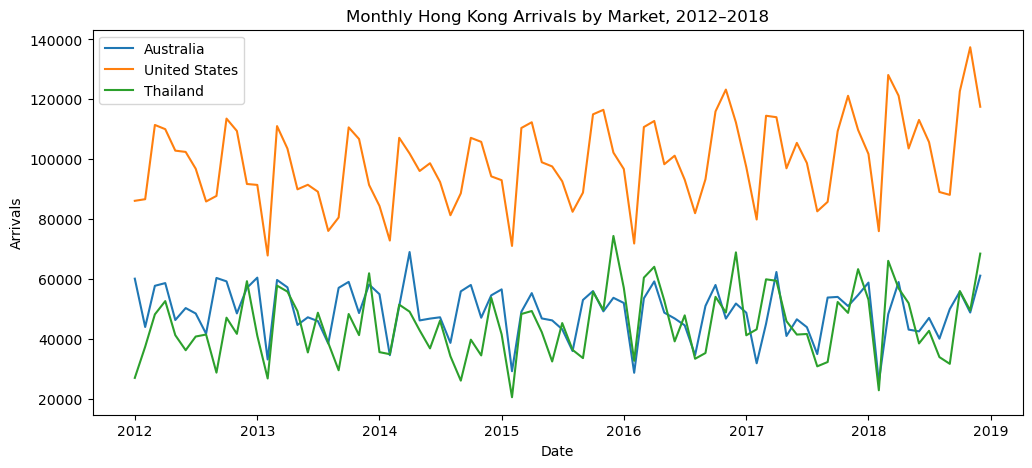

In [16]:
# time-series comparison figure showing monthly arrivals for the three required markets
fig, ax = plt.subplots(figsize=(12, 5))
for market in ["Australia", "United States", "Thailand"]:
    #source the values one market at a time 
    market_data = tidy_arrivals[tidy_arrivals["market"] == market] 
    ax.plot(market_data["date"], market_data["arrival"], label=market)
ax.set_title("Monthly Hong Kong Arrivals by Market, 2012–2018")
ax.set_xlabel("Date")
ax.set_ylabel("Arrivals")
ax.legend()
plt.show()

This graph shows the monthly arrivals in Hong Kong by three markets; Australia, United States, Thailand. We have the dates (2012-2018) on the x axis, and the number of arrivals on the y axis. From this graph, we can see that there is a larger number of arrivals from the United States compared to both Thailand and Australia, while the latter 2 have highly similar monthly arrival numbers across all years. 

In [17]:
#first to last comparison
year_2012 = annual_summary[annual_summary["year"] == 2012]
year_2018 = annual_summary[annual_summary["year"] == 2018]
#we will create a new table with our 2012 and 2018 total arrivals and merge based on market
growth_comparison = year_2012.merge(year_2018, on="market", suffixes=("_2012", "_2018"))
print(growth_comparison[["market", "annual_total_arrival_2012", "annual_total_arrival_2018"]])

          market  annual_total_arrival_2012  annual_total_arrival_2018
0      Australia                     632462                     580167
1       Thailand                     501759                     571606
2  United States                    1184757                    1304232


In [18]:
#now, we will calculate the percentage change for each of the markets 
growth_comparison["pct_change_2012_to_2018"] = (
    (growth_comparison["annual_total_arrival_2018"] - growth_comparison["annual_total_arrival_2012"])
    / growth_comparison["annual_total_arrival_2012"] * 100
)
growth_comparison["pct_change_2012_to_2018"] = growth_comparison["pct_change_2012_to_2018"].round(2)
print(growth_comparison[["market", "annual_total_arrival_2012", "annual_total_arrival_2018", "pct_change_2012_to_2018"]])

          market  annual_total_arrival_2012  annual_total_arrival_2018  \
0      Australia                     632462                     580167   
1       Thailand                     501759                     571606   
2  United States                    1184757                    1304232   

   pct_change_2012_to_2018  
0                    -8.27  
1                    13.92  
2                    10.08  


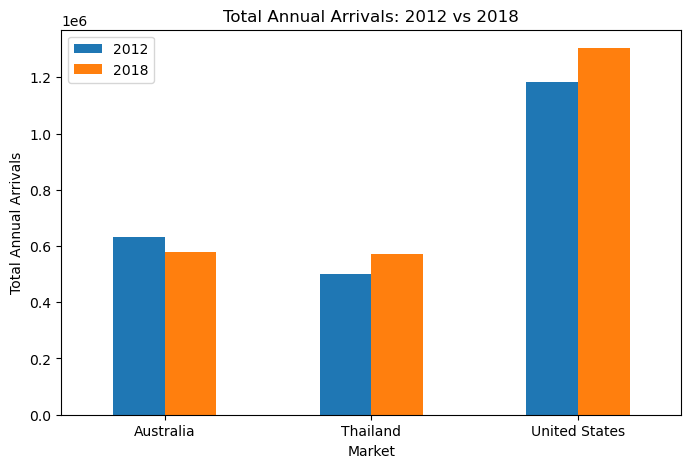

In [19]:
#uses market names for the x axis, and only plotting annual total arrival for 2012 and 2018
plot_data = growth_comparison.set_index("market")[["annual_total_arrival_2012", "annual_total_arrival_2018"]]
#setting column names 
plot_data.columns = ["2012", "2018"]

ax = plot_data.plot(kind="bar", figsize=(8, 5))
ax.set_title("Total Annual Arrivals: 2012 vs 2018")
ax.set_xlabel("Market")
ax.set_ylabel("Total Annual Arrivals")
plt.xticks(rotation=0)
plt.show()

This graph shows the total arrivals for each market in the years 2012 and 2018. As we can see, Australia had a decrease in arrivals to Hong Kong from 2012-2018, while Thailand and United States both had an increase. 

From our updated growth_comparison table, we can see the total arrivals for 2012 and 2018 for each of the markets. Then, we have also calculated the percentage change for each of the markets to compare the arrival totals at the start and the end of the data collection. As we can see, Australia was the only country with a decrease in total arrivals (-.8.27%) compared to Thailand (13.92%) and United States (10.08%). Thailand observed the largest growth in Hong Kong arrivals. 

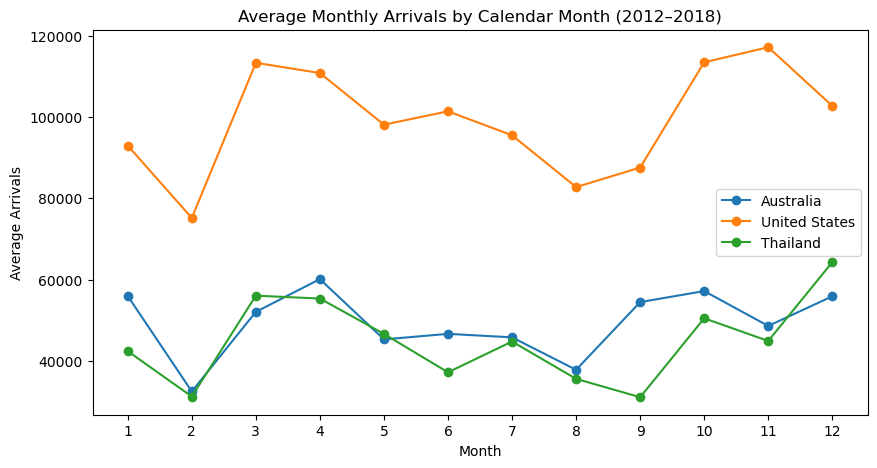

In [20]:
#Now, we will build a seasonal/month level view, as we saw fluctuations in the year in our first graph
month_data = tidy_arrivals.copy()
#creating a new month column with just the months 
month_data["month"] = month_data["date"].dt.month
#average arrival per month 
seasonal_pattern = month_data.groupby(["market", "month"])["arrival"].mean().reset_index()


fig, ax = plt.subplots(figsize=(10, 5))
for market in ["Australia", "United States", "Thailand"]:
    market_seasonal = seasonal_pattern[seasonal_pattern["market"] == market]
    #plot the month and arrival totals by market 
    ax.plot(market_seasonal["month"], market_seasonal["arrival"], marker="o", label=market)
ax.set_title("Average Monthly Arrivals by Calendar Month (2012–2018)")
ax.set_xlabel("Month")
ax.set_ylabel("Average Arrivals")
# x axis with labels 1-12
ax.set_xticks(range(1, 13))
ax.legend()
plt.show()

This graph highlights the average monthly arrivals across the years 2012-2018 per three markets; Australia, Thailand and the United States. As we can see, all markets follow a similar pattern. Arrivals dip in February, increase through March-May, dip again through June - September (Thailand only dips until August) and then increase again from October - December. 

               absolute_volatility  relative_volatility
market                                                 
Australia                  8712.69               0.1766
Thailand                  11244.18               0.2500
United States             13665.36               0.1377


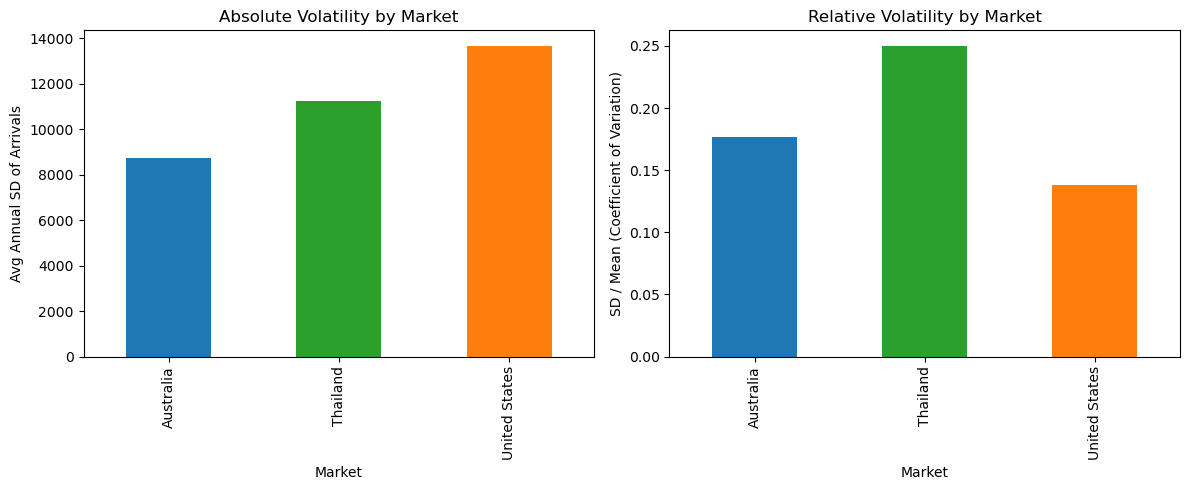

In [21]:
#Now we will do a quick volatility comparison
volatility_comparison = annual_summary.groupby("market")["annual_sd_arrival"].mean().round(2)

#relative volitlity:
relative_volatility = (annual_summary.groupby("market")["annual_sd_arrival"].mean() /
                        annual_summary.groupby("market")["annual_mean_arrival"].mean()).round(4)

#create a dataframe with both so we can plot them
volatility_table = pd.DataFrame({
    "absolute_volatility": volatility_comparison,
    "relative_volatility": relative_volatility
})
print(volatility_table)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#using 2 separate bar charts side by side as they have drastically different scales 

#assigning colours to each market 
market_colors = {"Australia": "tab:blue", "United States": "tab:orange", "Thailand": "tab:green"}
colors = [market_colors[market] for market in volatility_table.index]

#absolute volatility graph
volatility_table["absolute_volatility"].plot(kind="bar", ax=axes[0], color=colors)
axes[0].set_title("Absolute Volatility by Market")
axes[0].set_ylabel("Avg Annual SD of Arrivals")
axes[0].set_xlabel("Market")

#relative volatility graph
volatility_table["relative_volatility"].plot(kind="bar", ax=axes[1], color=colors)
axes[1].set_title("Relative Volatility by Market")
axes[1].set_ylabel("SD / Mean (Coefficient of Variation)")
axes[1].set_xlabel("Market")

plt.tight_layout()
plt.show()

Here, we have used the absolute volatility from our annual summary table, and calculated relative volatility by dividing each value by the mean. This gives us two different measurements: total volatility, and relative volaility. Total volatility will show the scale of monthly swings in arrivals within a year, while relative volatility tells us the scale of monthly swings in a year in proportion of the total arrivals. This wil allow us to compare markets of different sizes, as the United States is a larger market compared to Thailand and Australia. We have plotted these in two separate bar graphs, and as we can see the United States has the highest absolute volatility while Thailand has the greatest relative volatility. 

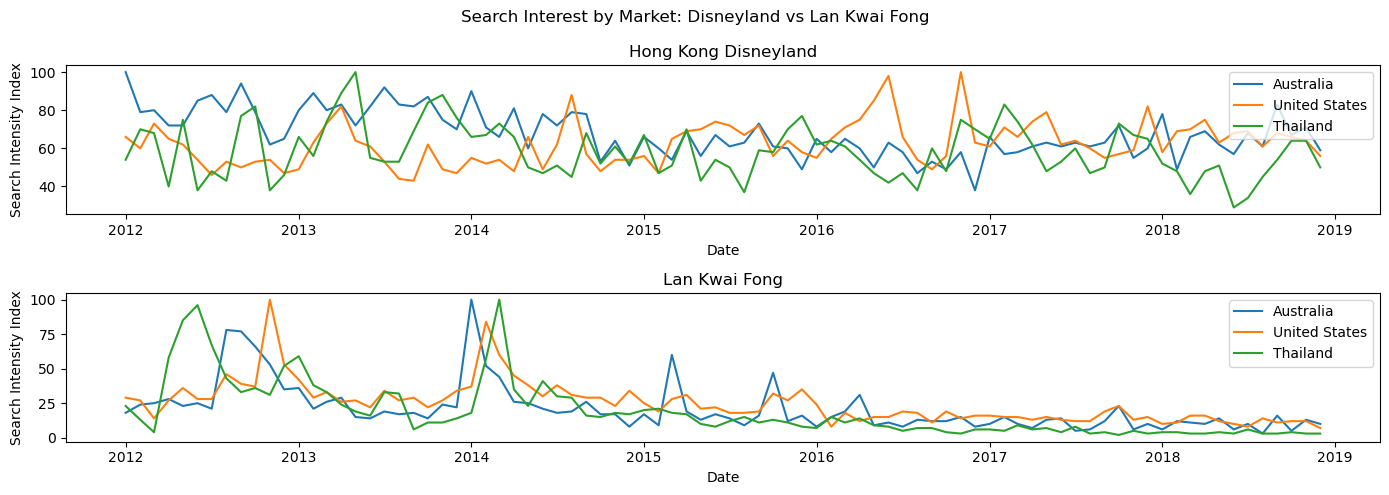

In [22]:
#Now, we will have a look at select SII columns. We have chosen different attractions in Hong Kong, namely:
#Hong kong disneyland and lan_kawi_fong (nightlife district) to see how they fluctuate over the years 
#First, we will plot disneyland searches 
#the plots are quite detailed and so we've gone for a stacked layout to see the data clearer 
fig, axes = plt.subplots(2,1, figsize=(14, 5))

#for loop sets the data in subplot 1 to disneyland and the subplot 2 to lan kawi fong
for market, df in clean_market_data.items():
    #plot date and the attraction to see how the search fluctuates throughout the year 
    axes[0].plot(df["date"], df["hong_kong_disneyland"], label=market)
    axes[1].plot(df["date"], df["lan_kwai_fong"], label=market)

fig.suptitle("Search Interest by Market: Disneyland vs Lan Kwai Fong")

axes[0].set_title("Hong Kong Disneyland")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Search Intensity Index")
axes[0].legend()

axes[1].set_title("Lan Kwai Fong")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Search Intensity Index")
axes[1].legend()

plt.tight_layout()
plt.show()

We have graphed the SII columns Hong Kong Disneyland and Lan Kwai Fong to compare the volume of searches from 2012-2018. We have used these columns as they are two popular attractions in Hong Kong. Disneyland searches may be more tailored to families, while the nightlife may cater to a younger crowd. This graph compares the difference in search volume for each market with these differing types of attractions in Hong kong.  As we can see, Hong Kong Disneyland searches are fairly stable throughout the years, with some fluctuations seen independently in each market (United States in 2016/2017). Lan Kwai Fong searches are also fairly stable but with more pronounced fluctuations seen simultaenously in all markets, such as in 2014. 

#### Your Q9 written comparison

<!-- A1:ANSWER:Q9:START -->
To explore the findings in our various graphs and tables, we will first examine the annual summary table. From this table, we can see the annual arrival total, mean and standard deviation for each year that was recorded (2012-2018). We also see the arrival total in the first and last month of each year. We can see that the United States has the largest number of arrivals for each month, essentially doubling the number of arrivals for Australia and Thailand. We also see that Australia and Thailand’s arrivals are very similar, consistently being between 40,000 and 60,000. From our Monthly Hong Kong Arrivals chart, the difference in the United States arrival totals and Australia/Thailand’s arrivals is quite stark. We can also see that all markets fluctuate in terms of arrivals throughout the year, and there seems to be a clear pattern every year. To examine this, built a graph for the average monthly arrivals across 2012-2018. From this, we can see clear patterns with increasing arrivals in March-May and September-December, with clear dips between May and August and January-February. Interestingly, all of the markets follow these fluctuations, indicating that trips may align with holidays and seasonal changes. 

We calculated the percentage difference between arrivals in the first and last years that the data was recorded (2012 vs 2018) in the growth comparison table and in our total annual arrivals bar chart. From this, we found that Australia experienced an 8% decrease in arrivals from 2012-2018, whereas Thailand and the United States experienced an increase in arrivals with 14% and 10% respectively, with Thailand experienced the largest increase in arrivals over time. We also investigated the trends in specific SII columns over the duration of the study. We used hong_kong_disneyland and lan_kwai_fong as these are popular tourist destinations/attractions in Hong Kong. We chose these columns as they differ greatly in the type of attraction they are, (family/wholesome vs night life/clubbing) to measure how these searches changed over time. For Disneyland, we saw a steady rate across the years, with very little fluctuations across all markets. There were few peaks within individual markets, such as the United States in 2016-2017, but for the most part each market followed its own steady pattern across the years. In comparison, Lan Kwai Fong had several fluctuations throughout the years, with big increases across all markets in 2013 and 2014, indicating there may have been some popular event or attraction happening there. For Lan Kwai Fong, fluctuations were much more cohesive across all of the markets compared to Disneyland searches. 

We also compared volatility to investigate how the standard deviation of monthly arrivals within each year in our volatility table. The United States showed the greatest absolute volatility (13,665) compared to Australia and Thailand, which is to be expected as the United States was the biggest market based on total arrivals. This can be seen in our absolute volatility graph, where the United States clearly has the greatest absolute volatility. In order to calculate volatility in proportion to the size of the market, we also calculated relative volatility. From these, we found Thailand to have the greatest relative volatility, indicating the largest changes in monthly arrivals in proportion to arrival numbers. This was observed in our relative volatility graph, where Thailand has the largest value with 0.25. 

<!-- A1:ANSWER:Q9:END -->

### Question 10: Feature engineering and SII analysis [15 marks]

Your task:

Create interpretable arrival features and analyse Search Intensity Index signals.

Your notebook should include a short written explanation of why the selected SII features were chosen and what their relationships with arrivals do and do not imply.

As a guide, write 1-2 short paragraphs explaining why the SII features were selected and what the observed relationships do and do not imply.

Search Intensity Index features should be identified from the original cleaned CSV columns before adding your own arrival-derived features. Exclude `date`, `market`, `arrival`, and any derived columns created by you.

The selected SII feature names must be traceable to columns in your cleaned data. Do not submit placeholder names such as `<cleaned_sii_column_1>` or `sii_feature_name_1`; your selected feature names must match columns in your cleaned original data.

Students may use correlation or co-movement to help select SII features, but high correlation or co-movement may reflect shared trends, seasonality, scale effects, or confounding. Do not present correlation as causal evidence.

If you use a figure to compare SII-arrival relationships, it should be clearly labelled and interpreted. A table-only comparison is acceptable if it clearly supports the written analysis.

You may reuse your Part I functions where appropriate. In particular, Question 4 can support numeric-column inspection and SII feature identification, Question 5 can support rolling-mean features, and Question 6 can support local peak/valley indicators. Equivalent correct implementations are also acceptable.

Required outputs:

- feature table containing the required derived fields;
- `selected_sii_features` as a list containing at least three selected original SII feature names;
- a transparent feature-selection rule;
- `sii_summary` with, for each selected feature and market, interpretable feature summaries and one relationship or co-movement measure with arrivals, such as correlation or another clearly explained measure;
- at least one comparison of an SII-arrival relationship across markets;
- explanation that correlation or co-movement is not causal evidence;
- clearly labelled feature and SII summary tables or figures where used.

Required object(s):

- `feature_table`
- `selected_sii_features`
- `sii_summary`

Required `feature_table` structure:

- pandas DataFrame with required columns `date`, `market`, `arrival`, `year`, `month`, `arrival_diff`, `arrival_pct_change`, `arrival_roll3_mean`, `arrival_roll12_mean`, `arrival_volatility_3`, `is_local_peak`, and `is_local_valley`;
- rolling features and local extrema must be computed within each market, not across the concatenated dataset.

Required derived-field definitions:

- `year`: calendar year extracted from `date`.
- `month`: calendar month extracted from `date`, preferably as an integer from 1 to 12.
- `arrival_diff`: month-to-month difference in `arrival` within each market.
- `arrival_pct_change`: month-to-month percentage change in `arrival` within each market. The first month for each market may be `NaN` or `None`.
- `arrival_roll3_mean`: trailing 3-month rolling mean of `arrival` within each market.
- `arrival_roll12_mean`: trailing 12-month rolling mean of `arrival` within each market.
- `arrival_volatility_3`: trailing 3-month rolling standard deviation of `arrival` within each market.
- `is_local_peak`: boolean indicator showing whether the month is a strict local peak in `arrival` within the same market.
- `is_local_valley`: boolean indicator showing whether the month is a strict local valley in `arrival` within the same market.

Required `selected_sii_features` structure:

- list of at least three selected original SII feature names from the cleaned original CSV columns;
- names must match columns in the cleaned original data;
- do not include `date`, `market`, `arrival`, or derived arrival features.

Required `sii_summary` structure:

- pandas DataFrame with required columns `market`, `feature`, `feature_mean`, `feature_sd`, `relationship_measure`, `relationship_value`, and `interpretation_note`;
- include one or more rows for each selected SII feature and market;
- `interpretation_note` should briefly state what the relationship measure suggests and what it does not prove.

Example `feature_table` structure, not complete results. Values shown as `...` must be computed from the dataset:

| date | market | arrival | year | month | arrival_diff | arrival_pct_change | arrival_roll3_mean | arrival_roll12_mean | arrival_volatility_3 | is_local_peak | is_local_valley |
| --- | --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | --- | --- |
| 2012-01-01 | Australia | ... | 2012 | 1 | ... | ... | ... | ... | ... | False | False |
| 2012-02-01 | Australia | ... | 2012 | 2 | ... | ... | ... | ... | ... | False | False |
| ... | ... | ... | ... | ... | ... | ... | ... | ... | ... | ... |

Example `selected_sii_features` structure. The feature names shown are structure-only placeholders, not actual required SII feature names:
```python
# Example structure only. Replace these with real column names from your cleaned data.
selected_sii_features = ["<cleaned_sii_column_1>", "<cleaned_sii_column_2>", "<cleaned_sii_column_3>"]
```
Do not submit placeholder names such as `<cleaned_sii_column_1>` or `sii_feature_name_1`; your selected feature names must match columns in your cleaned original data.

Example `sii_summary` structure, not complete results. The feature names shown are structure-only placeholders, not actual required SII feature names. The `interpretation_note` should briefly state what the relationship measure suggests and what it does not prove:

| market | feature | feature_mean | feature_sd | relationship_measure | relationship_value | interpretation_note |
| --- | --- | ---: | ---: | --- | ---: | --- |
| Australia | `<cleaned_sii_column_1>` | ... | ... | correlation | ... | ... |
| United States | `<cleaned_sii_column_1>` | ... | ... | correlation | ... | ... |
| Thailand | `<cleaned_sii_column_1>` | ... | ... | correlation | ... | ... |
| ... | ... | ... | ... | ... | ... | ... |


In [23]:
# Replace None with your completed object. Leaving this as None will not satisfy the requirement.
# This should be your completed feature table.

#empty list of feature frame
feature_frames = []
# we will build a for loop to calculate each market's values independently
for market, df in clean_market_data.items():
    #only need date and arrival columns 
    market_features = df[["date", "arrival"]].copy()
    #define our market column
    market_features["market"] = market
    #create a numerical year and month column
    market_features["year"] = market_features["date"].dt.year
    #month now ranges from 1 to 12 
    market_features["month"] = market_features["date"].dt.month
    #.diff will calculate monthly arrival differences 
    market_features["arrival_diff"] = market_features["arrival"].diff()
    market_features["arrival_pct_change"] = market_features["arrival"].pct_change()
    #we will use our function rolling_mean_manual from Q5
    #rolling features and local extrema are also being calculated within each market here 
    #we are converting arrival column to a list as it is currently a series for safety/preserve the original index 
    market_features["arrival_roll3_mean"] = rolling_mean_manual(market_features["arrival"].tolist(), window=3)
    market_features["arrival_roll12_mean"] = rolling_mean_manual(market_features["arrival"].tolist(), window=12)
    #for arrival volatility, we will use pandas built in .rolling function, providing the same function as our manual one to compute rolling std
    market_features["arrival_volatility_3"] = market_features["arrival"].rolling(window=3).std()
    #using to list to convert arrival column into a list to then pass into the function
    extrema = detect_local_extrema(market_features["arrival"].tolist())
    #checking whether each row's index position matches one of the peak/valley positions returned by detect_local_extrema
    market_features["is_local_peak"] = market_features.index.isin(extrema["peaks"])
    market_features["is_local_valley"] = market_features.index.isin(extrema["valleys"])
    feature_frames.append(market_features)
feature_table = pd.concat(feature_frames, ignore_index=True)
print(feature_table.head())

# Replace None with your completed object. Leaving this as None will not satisfy the requirement.
# This should be your list of at least three selected original SII feature names.
#We will select the three SII features based on correlation scores with arrival.
#First, we are creating a list of all of the column names excluding date and arrival. We are just using Australia as we only need the list of columns once. 
sii_candidate_columns = [col for col in clean_market_data["Australia"].columns if col not in ["date", "arrival"]]
#empty list for our correlation records 
correlation_records = []
#identifying SII from our clean market data
for market, df in clean_market_data.items():
    #for each column in our column list 
    for col in sii_candidate_columns:
        #calculate correlation between the columns in df and arrival
        correlation = df[col].corr(df["arrival"])
        #building a small dictionary for our results 
        correlation_records.append({"market": market, "feature": col, "correlation": correlation})
#create a data frame with out dictionaries of results        
correlation_table = pd.DataFrame(correlation_records)
#We are going to use absolute value to identify the strongest correlation regardless of direvtion (positive vs negative)
correlation_table["abs_correlation"] = correlation_table["correlation"].abs()
#printing the top 10 highest average correlation for each feature across all markets 
feature_avg_correlation = correlation_table.groupby("feature")["abs_correlation"].mean().sort_values(ascending=False).round(2)
print(feature_avg_correlation.head(10))

        date  arrival     market  year  month  arrival_diff  \
0 2012-01-01    60116  Australia  2012      1           NaN   
1 2012-02-01    43982  Australia  2012      2      -16134.0   
2 2012-03-01    57736  Australia  2012      3       13754.0   
3 2012-04-01    58640  Australia  2012      4         904.0   
4 2012-05-01    46312  Australia  2012      5      -12328.0   

   arrival_pct_change  arrival_roll3_mean  arrival_roll12_mean  \
0                 NaN                 NaN                  NaN   
1           -0.268381                 NaN                  NaN   
2            0.312719        53944.666667                  NaN   
3            0.015657        53452.666667                  NaN   
4           -0.210232        54229.333333                  NaN   

   arrival_volatility_3  is_local_peak  is_local_valley  
0                   NaN          False            False  
1                   NaN          False             True  
2           8709.600756          False            

From this, we can see the top SII features with the highest correlation value with arrival. The highest 3 are hong_kong, hong_kong_weather and festival_hong_kong. Based on these correlation scores, we can infer that the SII features have a moderate - weak correlation, with the highest score only being 0.31. To select our features, we are going to use the three features with the highest absolute correlation score. In this case, we are going to use hong_kong, hong_kong_weather, and festival_hong_kong. We have used the absolute value so it is not clear if these correlations are positive or negative, which we will explore in the next table. 

In [24]:
selected_sii_features = feature_avg_correlation.head(3).index.tolist()
print(selected_sii_features)

['hong_kong', 'hong_kong_weather', 'festival_hong_kong']


Now, to investigate the correlation between each feature and arrival, we will build an sii summary table.

In [25]:
# empty list for our results 
sii_summary_records = []
# loop for each market in clean market data
for market, df in clean_market_data.items():
    #only pulling results for our selected sii features 
    for feature in selected_sii_features:
        # feature mean and std by searching for each feature in our df 
        feature_mean = df[feature].mean()
        feature_std = df[feature].std()
        relationship_value = df[feature].corr(df["arrival"])
        # for our interpretation note, we will use several if/else statements to construct a note 
        #state direction in our note 
        if relationship_value > 0:
            direction = "positive"
        else:
            direction = "negative"
        #state strength of the relationship
        if abs(relationship_value) >= 0.5:
            strength = "moderate to strong"
        elif abs(relationship_value) >= 0.3:
            strength = "moderate"
        else:
            strength = "weak"
        #use our stored variables to state the relationship between the feature and arrival, and state what it doesn't show
        interpretation_note = (
            f"There is a {strength} {direction} correlation between {feature} and arrival in {market}. "
            "This suggests the two may move together, but correlation does not imply causation and may reflect shared trends, seasonality, or other confounding factors."
                )
        #append the results to our empty list and create a dictionary 
        sii_summary_records.append({
            "market": market,
            "feature": feature,
            "feature_mean": round(feature_mean, 2),
            "feature_sd": round(feature_std, 2),
            "relationship_measure": "correlation",
            "relationship_value": round(relationship_value, 2),
            "interpretation_note": interpretation_note
        })
sii_summary = pd.DataFrame(sii_summary_records)
#sort values by feature in order of highest correlation score from our list before 
feature_order = ["hong_kong", "hong_kong_weather", "festival_hong_kong"]
#sorting by feature will recreate the built in order of Australia, United States and then Thailand 
sii_summary["feature"] = pd.Categorical(sii_summary["feature"], categories=feature_order, ordered=True)
sii_summary = sii_summary.sort_values("feature").reset_index(drop=True)
print(sii_summary)

          market             feature  feature_mean  feature_sd  \
0      Australia           hong_kong         76.43        8.42   
1  United States           hong_kong         64.06        5.22   
2       Thailand           hong_kong         84.35        8.04   
3      Australia   hong_kong_weather         48.52       12.35   
4  United States   hong_kong_weather         51.46       10.89   
5       Thailand   hong_kong_weather         56.56       16.83   
6      Australia  festival_hong_kong         36.96       19.19   
7  United States  festival_hong_kong         46.92       17.13   
8       Thailand  festival_hong_kong         35.36       27.29   

  relationship_measure  relationship_value  \
0          correlation                0.41   
1          correlation                0.07   
2          correlation                0.45   
3          correlation                0.37   
4          correlation                0.04   
5          correlation                0.50   
6          correl

#### Your Q10 SII interpretation

<!-- A1:ANSWER:Q10:START -->
For our SII feature selection, we have decided to use Pearson correlation to measure the relationship between SII features and arrivals. Pearson correlation measures the strength and direction of the linear relationship between 2 variables, and in this case, we measured the linear relationship between arrival and our SII features. Pearson correlation ranges from -1 to 1, with a score of -1 indicating that the relationship is a perfect negative linear relationship, while a value of 1 indicates it is a perfect positive linear relationship. A limitation of this score is that it only captures the linear relationship, and therefore won’t be able to effectively capture non-linear relationships in this dataset. To determine which SII features we will select, we are going to use the three features with the highest absolute correlation score. We have decided to use the absolute value because we want to capture the features with the strongest correlation with arrival regardless of direction. To do this, we first calculated the correlation of each feature with arrival, and then ranked absolute correlation. From this, we identified our three features as ‘hong_kong’, ‘hong_kong_weather’ and ‘festival_hong_kong’.  

In our SII summary table, we found the correlation of each of the features with arrival in each market, resulting in a table with 9 rows. To determine strength of correlation, we used the scale of x≥0.5 = moderate to strong, 0.3≤x<0.5 = moderate, and x<0.3 = weak, for absolute correlation values. From this table, we can see that ‘hong_kong’ has a moderate positive correlation with Australia and Thailand, but a weak correlation with the United States. For ‘hong_kong_weather’, we can see that there was a weak positive correlation with the United States, but a moderate relationship with Australia and Thailand. We can also see that ‘festival_hong_kong’ had a weak positive relationship with Australia and Thailand, but there was a moderate negative relationship with the United States (-0.41). This indicates that ‘festival_hong_kong’ searches had a positive correlation in all markets except for the United States. For any positive correlation that we saw, we can only imply that the feature had a positive linear relationship with arrivals, and negative correlations indicate that there was a negative linear relationship with arrivals. From this correlation score, we can not determine any causal relationships, and this score does not determine which features lead to more or less arrivals. This correlation score can only capture shared trends, seasonality, scale effects or confounding. 
<!-- A1:ANSWER:Q10:END -->

### Question 11: Critical interpretation, limitations, and project-planning insight [10 marks]

Your task:

Write a short evidence-based analysis in your notebook and exported PDF. This question is primarily assessed through your written interpretation, not through additional code.

As a guide, write approximately 300-500 words, or 3-5 concise paragraphs, supported by your tables and figures.

Required written answer:

- summarise the main findings about the three required markets;
- explain what the Search Intensity Index signals appear to support;
- explain what the Search Intensity Index signals cannot support;
- discuss limitations of the data and your descriptive analysis;
- explain what a later modelling or forecasting project would need to handle;
- make clear links to the relevant tables and figures in your notebook and exported PDF.

Formal forecasting is outside Assignment 1. Do not replace the required descriptive analysis with a forecasting model.


#### Your Q11 written answer

<!-- A1:ANSWER:Q11:START -->
From our annual summary table, we found that the United States is the largest market in terms of Hong Kong arrivals. We found that the annual total arrival of the United States from 2012-2018 sits consistently around 100,000 – 130,000, while both Australia and Thailand arrivals sit approximately between 50,000 – 65,000. We calculated the difference between 2012 and 2018 total arrivals for each market in the growth comparison table and found that all markets observed an increase in arrivals above 10% except for Australia, which had an 8% decrease in arrivals. From our monthly Hong Kong Arrivals chart, we can see that each of the markets follow fluctuations throughout the year, indicating there are seasonal and monthly patterns. To further investigate this, we plotted average monthly arrivals across all years in the seasonal pattern chart and found that all markets follow a similar pattern; arrivals rise between March and May, dip between June and August, then rise again between September and December, followed by a minor dip between January and February. In the volatility tabler we calculated the average deviation between months for each year, and found that the United States had the highest absolute volatility while Thailand had the highest relative volatility. Lastly, we investigated Search Interest for Disneyland and Lan Kwai Fong. From this, we observed that Disneyland searches are consistent across all markets throughout the years, while Lan Kwai Fong had several rises and dips consistent across all markets. 

From our SII signal selection and summary table, we found the three signals with the highest Pearson correlation with arrivals. From this, we determined the strength and direction of the linear relationship between each signal and arrivals within each market. We found that ‘hong_kong’, ‘hong_kong_weather’ and ‘festival_hong_kong’ had the highest absolute correlation scores. From this, we found in our SII summary table the correlation strength and direction in each market. This finding supports the observed association each feature has with arrivals, and the strength of that positive or negative relationship. This information supports any shared trends, seasonality, scale effects or confounding that may be worth investigating further and highlights any potential relationships. The SII summary table and selected features do not support causal relationships within this data. This data only supports how the features correlate with the arrival totals, but this does not determine any causal relationship between the features and arrivals. 

A limitation of the data is that there is no demographic or individual level information about who is searching or arriving. This could have provided further insight into which demographics are searching for specific signals. From our analysis, we only used Pearson correlation to assess the relationship between arrivals and SII signals. This would only capture linear relationships, and thus we were not able to see how SII signals are related in terms of non-linear relationships. There were also only three markets considered in this analysis, which limits the information retained for the relationship between arrival totals and SII signals. 

A later project would need to handle market specific relationships. From our data, we observed great variance in how SII signals were related to markets, such as in our sii summary table where ‘festival_hong_kong’, which was positively associated with Thailand and Australia, but negatively associated with the United States. A later project should also handle how search interests may impact arrival numbers in the following months. This would help to investigate how search interests impact arrivals. Lastly, a future model should investigate the seasonality fluctuations we saw in our model. 
<!-- A1:ANSWER:Q11:END -->

## Part III: Transfer and Reflection

Part III is worth 10 marks. Complete Question 12 as a discussion/reflection task.

You are not required to download, clean, transform, model, or fully analyse the `ISF-TDF2023` dataset for Assignment 1.

Reference dataset:
https://github.com/tulip-lab/open-data/blob/main/ISF-TDF2023/README.md

At the time of preparing this assignment, the `ISF-TDF2023` README describes a monthly Chinese outbound tourism-demand dataset with multiple destination series and documented historical, validation, and evaluation periods. Base your discussion on the README available when you complete the assignment.

### Question 12: Transfer and reflection [10 marks]

Your task:

Write a short reflection explaining how the functions, objects, and workflow you developed in Part I and Part II could be transferred or adapted to the `ISF-TDF2023` dataset.

This is a reflection task only. Do not add a full ISF-TDF2023 data-loading, cleaning, analysis, modelling, or forecasting workflow to your notebook.

Do not download, clean, transform, model, forecast, or fully analyse ISF-TDF2023 for this assignment. Do not include computed results from the ISF-TDF2023 CSV file. Base your answer on the public README and your understanding of transferability from Parts I and II.

As a guide, write approximately 250-400 words, or 2-4 concise paragraphs.

Required written answer:

- identify which Part I functions could transfer directly and which would need adaptation;
- explain which Part II objects or workflow stages have a useful equivalent for a multi-destination monthly tourism-demand dataset;
- discuss at least two dataset differences that would affect transfer, such as the number of destination series, different date coverage, historical/validation/evaluation periods, missing values, or forecasting-evaluation context;
- explain how you would check the new dataset before reusing your A1 workflow;
- state one limitation or risk of transferring a workflow from `HK2012-2018` to `ISF-TDF2023` without redesign.

Your answer should refer to the public `ISF-TDF2023` README at a high level. It should not include computed results from the `ISF-TDF2023` CSV file.


#### Your Q12 transfer reflection

<!-- A1:ANSWER:Q12:START -->
The ISF-TDF2023 dataset contains information on Chinese outbound tourism for 20 destination countries/regions over multiple regime periods. The functions from part 1 that could directly transfer are normalise_column_labels, summarise_numeric_columns, rolling_mean_manual and detect_local_extrema. These would all apply directly as they are general functions applied to any data. The functions that would need to be adapted are validate_monthly_date_range, as our current function has starts in 2012 and ends in 2018, but ISF-TDF2023 contains a range of start and end points up to 2024. Make_tidy_arrival_table also needs to be altered, as our current table only handles 3 destinations from 3 different files but would need to handle 20 destinations from a single file. 

The raw_market_data and schema_audit are directly transferrable concepts, as it would still be necessary to file and audit the data. The main difference would be that the output of raw_market_data would be one file with 20 destinations, and the schema audit would check each destination. Clean_market_data and tidy arrivals would still be useful, as it would be required to clean and produce a tidy arrivals table. Annual summary would be useful to assess arrivals within each destination. The feature table could be used to assess rolling means, differences and percentage change between months, but the table would need to be computed for each destination and within each regime period. Lastly, the exploratory data analysis through graphs could still be applied, but would need to consider 20 destinations instead of 3, and the distinct time periods. 

Two main differences between the datasets are that there are only 3 markets in HK2012-2018 and 20 destinations in ISF-TDF2023, and there are no missing values in HK2012-2018, while there are documented missing values in ISF-TDF2023. 

Before re-using this workflow, I would run a similar style schema-audit check to describe the dataset. This would give important information on row/column counts, date range and missing value counts, numeric column information, and column name issues. This would identify any outstanding cleaning requirements before implementing any functions or analysis, while identifying limits with the dataset. 

A risk of transferring the workflow from HK2012-2018 to ISF-TDF2023 would having to deal with missing cells/null values. In our HK2012-2018 set, we knew that there were no missing cells from the description of the data and by checking ourselves. Since our HK2012-2018 dataset was never tested against missing values, directly using functions such as rolling_mean_manual and detect_local_extrema would behave unpredictably around the missing values in ISF-TDF2023.
<!-- A1:ANSWER:Q12:END -->

## Dataset Source and Acknowledgement Placeholder

This assignment uses the TULIP Lab HK2012-2018 dataset, publicly available at
https://github.com/tulip-lab/open-data/tree/main/HK2012-2018.

Dataset associated with:
Zhang, Y., Li, G., Muskat, B., & Law, R. (2020). Tourism Demand Forecasting: A Decomposed
Deep Learning Approach. Journal of Travel Research. https://doi.org/10.1177/0047287520919522

## Reproducibility Checklist

Before exporting your PDF, check that:

- the notebook runs from top to bottom;
- the approved raw URL base is used;
- all required output object names, including `schema_audit`, are present;
- figures and tables are generated by the notebook;
- figures and tables are clearly labelled;
- the Part III reflection is included;
- package imports are clear;
- no local absolute paths or credentials are included;
- the dataset source is acknowledged.

## Submission Checklist

Submit through CloudDeakin via Assignments located under Assessment:

- completed notebook: `SIT742-2026T2-A1-<StudentID>.ipynb`
- exported PDF: `SIT742-2026T2-A1-<StudentID>.pdf`
- optional or requested video: `SIT742-2026T2-A1-<StudentID>-video.<ext>`

Replace `<StudentID>` with your Deakin student ID.

Students aiming for High Distinction are encouraged to submit a 3-5 minute video as supporting evidence. The video is not a separate scored component and does not replace the notebook or exported PDF. It should use efficient compression where possible, be 20 MB or less where possible, and show screen recording with voice and face camera visible. Not submitting an optional video does not automatically reduce your mark, but requested verification evidence should be provided if the teaching team asks for it.

If you have a technical, accessibility, or approved privacy-related reason that prevents this video format, follow the unit-site instructions or contact the teaching team before submission.
